# Train YOLO Model on RealWaste Dataset

## Install Dependencies

We use UV to manage packages because it is reproducible.

### NVIDIA GPU (CUDA)

torch-cuda will be automatically installed for windows users.

### Macbook (MPS)

No specific torch version required.

### Intel GPU (XPU)

Supported for Intel Arc and newer GPUs.

torch-xpu will be automatically installed for linux users.

### CPU Only

Not recommended.

```bash
uv sync
```

## Directory Tree

- datasets/
    - RealWaste/
        - Cardboard/
        - Food Organics/
        - Glass/
        - Metal/
        - Miscellaneous Trash/
        - Paper/
        - Plastic/
        - Textile Trash/
        - Vegetation/

## Set up torch

### NVIDIA GPU (CUDA)


In [ ]:

import torch

print(f"PyTorch Version: {torch.__version__}")
# You want to see something like: 2.9.1+cu121
# If you see just '2.9.1', it is still the CPU version.

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch Version: 2.5.1+cu124
CUDA Available: True
CUDA Available: True
Current GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## Intel GPU (XPU)

In [2]:
import torch

print(f"PyTorch Version: {torch.__version__}")

print(f"XPU Available: {torch.xpu.is_available()}")

if torch.xpu.is_available():
    print(f"Current GPU: {torch.xpu.get_device_name(0)}")

device_str = 'xpu' if torch.xpu.is_available() else 'cpu'
device = torch.device('xpu' if torch.xpu.is_available() else 'cpu')

PyTorch Version: 2.9.1+xpu
XPU Available: True
Current GPU: Intel(R) Graphics [0x64a0]


In [3]:
# Ultralytics has hardcoded CUDA calls that break on XPU
# Monkey-patch functions to work with XPU
import torch
from ultralytics import YOLO
import ultralytics.engine.trainer as trainer_module
import ultralytics.engine.validator as validator_module
import ultralytics.utils.torch_utils as torch_utils_module
import ultralytics.utils.checks as checks_module
import ultralytics.utils as utils_module
import gc

def _get_memory_xpu(self, fraction=False):
    """XPU-compatible memory getter."""
    memory = torch.xpu.memory_reserved() if hasattr(torch.xpu, 'memory_reserved') else 0
    if fraction:
        return 0.1  # Return low fraction to skip memory clearing
    return memory / 2**30

def _clear_memory_xpu(self, threshold=0.5):
    """XPU-compatible memory clearing."""
    gc.collect()
    if hasattr(torch.xpu, 'empty_cache'):
        torch.xpu.empty_cache()

# Patch the select_device function to handle XPU
_original_select_device = torch_utils_module.select_device

def select_device_xpu(device="", newline=False, verbose=True):
    """XPU-aware device selector."""
    device_str = str(device).strip().lower()
    if device_str == "xpu" or (hasattr(device, 'type') and device.type == 'xpu'):
        if torch.xpu.is_available():
            return torch.device('xpu')
    return _original_select_device(device, newline, verbose)

# Patch check_amp to avoid CUDA-only probing on non-CUDA builds (XPU/CPU)
_original_check_amp = checks_module.check_amp

def check_amp_safe(model):
    try:
        if hasattr(torch, "xpu") and torch.xpu.is_available():
            return False
        if not torch.cuda.is_available():
            return False
    except Exception:
        return False
    return _original_check_amp(model)

checks_module.check_amp = check_amp_safe
# BaseTrainer imports check_amp into its module namespace, so patch there too
trainer_module.check_amp = check_amp_safe

# Apply all patches
trainer_module.BaseTrainer._get_memory = _get_memory_xpu
trainer_module.BaseTrainer._clear_memory = _clear_memory_xpu

# Patch select_device everywhere it's imported
torch_utils_module.select_device = select_device_xpu
trainer_module.select_device = select_device_xpu
validator_module.select_device = select_device_xpu

# Also patch in ultralytics.utils (where it might be imported from)
utils_module.torch_utils.select_device = select_device_xpu

## Data Preparation

In [4]:
from pathlib import Path

dataset_path = Path('datasets/RealWaste')
processed_path = Path('datasets/processed')
train_path = processed_path / 'train'
val_path = processed_path / 'val'

In [4]:
import shutil
import random


if processed_path.exists():
    shutil.rmtree(processed_path)

train_path.mkdir(parents=True, exist_ok=True)
val_path.mkdir(parents=True, exist_ok=True)

classes = [d.name for d in dataset_path.iterdir() if d.is_dir()]
print(f"Found classes: {classes}")

# Split ratio
split_ratio = 0.8

for class_name in classes:
    class_dir = dataset_path / class_name
    images = list(class_dir.glob('*.jpg'))
    random.shuffle(images)
    
    split_idx = int(len(images) * split_ratio)
    train_images = images[:split_idx]
    val_images = images[split_idx:]
    
    # Create class directories in train and val
    (train_path / class_name).mkdir(exist_ok=True)
    (val_path / class_name).mkdir(exist_ok=True)
    
    for img in train_images:
        shutil.copy(img, train_path / class_name / img.name)
        
    for img in val_images:
        shutil.copy(img, val_path / class_name / img.name)
        
    print(f"Processed {class_name}: {len(train_images)} train, {len(val_images)} val")


Found classes: ['Food Organics', 'Glass', 'Vegetation', 'Paper', 'Plastic', 'Textile Trash', 'Metal', 'Miscellaneous Trash', 'Cardboard']
Processed Food Organics: 328 train, 83 val
Processed Glass: 336 train, 84 val
Processed Vegetation: 348 train, 88 val
Processed Paper: 400 train, 100 val
Processed Plastic: 736 train, 185 val
Processed Textile Trash: 254 train, 64 val
Processed Metal: 632 train, 158 val
Processed Miscellaneous Trash: 396 train, 99 val
Processed Cardboard: 368 train, 93 val


## Train

In [6]:
model = YOLO('yolo11n-cls.pt')  # load a pretrained model (recommended for training)

# Ultralytics uses AMP auto-checks that hard-require CUDA; disable AMP on XPU/CPU builds
amp_flag = False if device_str in {'xpu', 'cpu'} else True

results = model.train(
    data=str(processed_path.absolute()),
    epochs=14,
    imgsz=224,
    device=device_str,
    amp=amp_flag,
 )


engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/user/projects/ai-plastic-spotter/train/datasets/processed, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=14, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, projec

## Test

Top prediction: Plastic (0.993)
  Plastic: 0.993
  Paper: 0.003
  Miscellaneous Trash: 0.002
  Textile Trash: 0.001
  Glass: 0.000


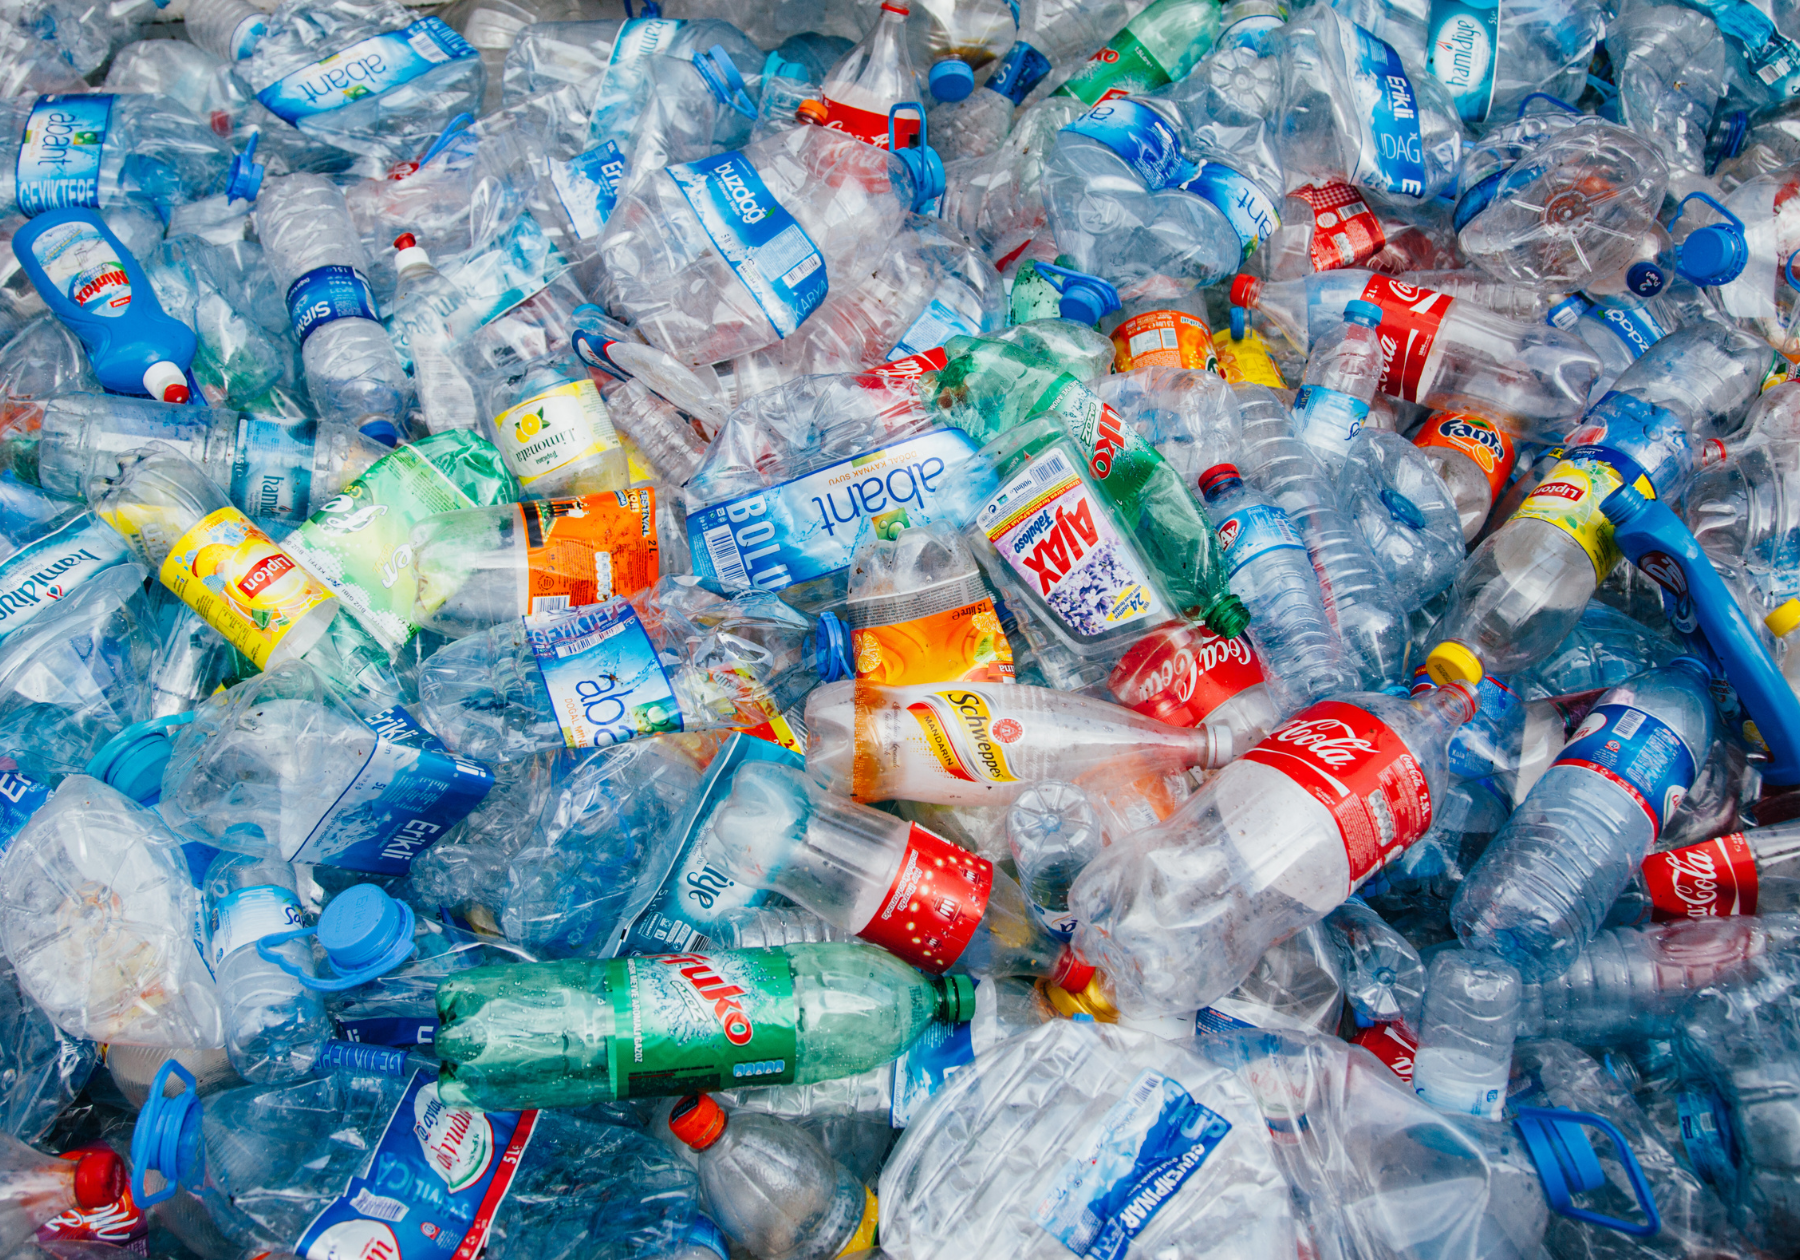

In [7]:
best_weights = Path('../runs/classify/train7/weights/best.pt')
if not best_weights.exists():
    raise FileNotFoundError(f"{best_weights} not found; rerun training or adjust the path.")

test_image = Path('plastic-bottle-waste.png')
if not test_image.exists():
    raise FileNotFoundError(f"{test_image} not found; place the sample image alongside the notebook.")

infer_model = YOLO(str(best_weights))
results = infer_model.predict(source=str(test_image), imgsz=640, conf=0.3, verbose=False)
result = results[0]

if hasattr(result, 'probs') and result.probs is not None:
    probs = result.probs
    top_idx = int(probs.top1)
    top_label = result.names[top_idx]
    print(f"Top prediction: {top_label} ({float(probs.top1conf):.3f})")
    # Print the top few confidences exposed by the Probs helper
    for idx, conf in zip(probs.top5, probs.top5conf):
        label = result.names[idx]
        print(f"  {label}: {float(conf):.3f}")
else:
    print('Unexpected output format; check that the model is a classification checkpoint.')

# Display the test image that was classified
from PIL import Image
from IPython.display import display
display(Image.open(test_image))